# 🔬 Eye Disease Prediction with GradCAM++
**Model:** Dual-Stream Swin-Tiny + Spatial Cross-Attention  
**Requires:** `best_model.pth`, `transmodel.pkl`, `transscaler.pkl`

In [1]:
# =========================================================
# CELL 0: INSTALL DEPENDENCIES
# =========================================================
!pip install -q timm albumentations grad-cam opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# =========================================================
# CELL 1: IMPORTS
# =========================================================
import pickle
import cv2
import timm
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import albumentations as A

from torch import nn
from PIL import Image
from pathlib import Path

# GradCAM++ from pytorch-grad-cam
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device : {device}")

✓ Device : cpu


In [3]:
# =========================================================
# CELL 2: MODEL ARCHITECTURE (must match training exactly)
# =========================================================

class CrossAttention(nn.Module):
    """
    Multi-head Cross-Attention + FFN.
    Q = Deep tokens (B,49,768), K/V = Shallow tokens (B,784,768)
    Output = (B,49,768)
    """
    def __init__(self, dim, num_heads=8, dropout=0.1, ffn_ratio=2):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.q_proj   = nn.Linear(dim, dim, bias=False)
        self.k_proj   = nn.Linear(dim, dim, bias=False)
        self.v_proj   = nn.Linear(dim, dim, bias=False)
        self.out_proj = nn.Linear(dim, dim, bias=False)

        self.norm_q   = nn.LayerNorm(dim)
        self.norm_k   = nn.LayerNorm(dim)
        self.norm_ffn = nn.LayerNorm(dim)
        self.dropout  = nn.Dropout(dropout)

        ffn_dim = dim * ffn_ratio
        self.ffn = nn.Sequential(
            nn.Linear(dim, ffn_dim, bias=False),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, dim, bias=False),
            nn.Dropout(dropout),
        )

    def forward(self, deep_tokens, shallow_tokens):
        B, Nq, D = deep_tokens.shape
        Nk       = shallow_tokens.shape[1]

        Q = self.q_proj(self.norm_q(deep_tokens))
        K = self.k_proj(self.norm_k(shallow_tokens))
        V = self.v_proj(shallow_tokens)

        Q = Q.view(B, Nq, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(B, Nk, self.num_heads, self.head_dim).transpose(1, 2)

        attn = torch.softmax(
            torch.matmul(Q, K.transpose(-2, -1)) * self.scale, dim=-1
        )
        attn = self.dropout(attn)

        out = torch.matmul(attn, V)
        out = out.transpose(1, 2).contiguous().view(B, Nq, D)
        out = self.out_proj(out)
        out = out + deep_tokens
        out = out + self.ffn(self.norm_ffn(out))
        return out


class SwinCrossAttnEyeDisease(nn.Module):
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()
        self.swin = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=False,
            features_only=True,
            out_indices=(1, 3),
            drop_path_rate=0.2,
        )

        shallow_dim, deep_dim = 192, 768

        # Token-wise projection: (B, 784, 192) → (B, 784, 768)
        self.shallow_proj = nn.Sequential(
            nn.Linear(shallow_dim, deep_dim, bias=False),
            nn.LayerNorm(deep_dim),
        )

        # Direct shallow GAP shortcut: (B, 192) → (B, 768)
        self.shallow_gap_proj = nn.Sequential(
            nn.Linear(shallow_dim, deep_dim, bias=False),
            nn.LayerNorm(deep_dim),
            nn.GELU(),
        )

        self.cross_attn  = CrossAttention(dim=deep_dim, num_heads=8,
                                          dropout=0.1, ffn_ratio=2)

        # Fusion: cat[deep_gap(768), attended_gap(768), shallow_gap(768)] → 768
        self.fusion_proj = nn.Sequential(
            nn.Linear(deep_dim * 3, deep_dim, bias=False),
            nn.LayerNorm(deep_dim),
            nn.GELU(),
            nn.Dropout(0.3),
        )

        self.norm = nn.LayerNorm(deep_dim)

        # ✅ MUST be named mlp_head — matches saved state_dict keys
        self.mlp_head = nn.Sequential(
            nn.Linear(deep_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),      # 0.5
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(dropout / 2),  # 0.25
            nn.Linear(64, num_classes),
        )

    def _extract(self, x):
        feats = self.swin(x)

        shallow_map = feats[0]   # (B, 28, 28, 192)  BHWC from timm Swin
        deep_map    = feats[1]   # (B,  7,  7, 768)

        B = x.shape[0]

        shallow_tokens = shallow_map.reshape(B, -1, 192)           # (B, 784, 192)
        deep_tokens    = deep_map.reshape(B, -1, 768)              # (B,  49, 768)

        # Stream 1: Deep GAP
        deep_gap = deep_tokens.mean(dim=1)                         # (B, 768)

        # Stream 2: Cross-attended deep tokens
        shallow_proj  = self.shallow_proj(shallow_tokens)          # (B, 784, 768)
        attended      = self.cross_attn(deep_tokens, shallow_proj) # (B,  49, 768)
        attended_gap  = attended.mean(dim=1)                       # (B, 768)

        # Stream 3: Shallow direct shortcut
        # shallow_map is (B, H, W, C) → GAP over H,W → (B, 192)
        shallow_raw_gap = shallow_map.mean(dim=(1, 2))             # (B, 192)
        shallow_gap     = self.shallow_gap_proj(shallow_raw_gap)   # (B, 768)

        # 3-way fusion
        fused = self.fusion_proj(
            torch.cat([deep_gap, attended_gap, shallow_gap], dim=1)  # (B, 2304)
        )                                                             # (B, 768)

        return self.norm(fused)

    def forward(self, x):
        return self.mlp_head(self._extract(x))

    def extract_features(self, x):
        """768-dim features for t-SNE / downstream tasks."""
        return self._extract(x)

print("✓ SwinCrossAttnEyeDisease architecture defined (mlp_head, _extract).")


✓ SwinCrossAttnEyeDisease architecture defined (mlp_head, _extract).


In [4]:
# =========================================================
# CELL 3: LOAD PKL METADATA + MODEL WEIGHTS
# =========================================================
# ── Paths — change these if your files are elsewhere ──────
PKL_MODEL_PATH   = "transmodel.pkl"      # class names, display names, colors
PKL_SCALER_PATH  = "transscaler.pkl"     # preprocessing config
MODEL_WEIGHTS    = "best_model.pth"      # trained state_dict
# ──────────────────────────────────────────────────────────

# 1. Load metadata
with open(PKL_MODEL_PATH, "rb") as f:
    model_meta = pickle.load(f)

with open(PKL_SCALER_PATH, "rb") as f:
    scaler_meta = pickle.load(f)

CLASS_NAMES   = model_meta["class_names"]    # ["cataract", "diabetic_retinopathy", ...]
DISPLAY_NAMES = model_meta["display_names"]  # ["Cataract", "Diabetic Retinopathy", ...]
CLASS_COLORS  = model_meta["class_colors"]
NUM_CLASSES   = model_meta["num_classes"]
INPUT_SIZE    = model_meta["input_size"]     # 224

MEAN = scaler_meta["normalize_mean"]
STD  = scaler_meta["normalize_std"]
CLAHE_CLIP    = scaler_meta["clahe_clip_limit"]
CLAHE_TILE    = scaler_meta["clahe_tile_grid_size"]

print(f"✓ Loaded metadata from {PKL_MODEL_PATH}")
print(f"  Classes  : {DISPLAY_NAMES}")
print(f"  Norm mean: {MEAN}")
print(f"  Norm std : {STD}")

# 2. Build model and load weights
model = SwinCrossAttnEyeDisease(num_classes=NUM_CLASSES).to(device)

checkpoint = torch.load(MODEL_WEIGHTS, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"\n✓ Loaded weights from {MODEL_WEIGHTS}")
print(f"  Architecture : {checkpoint.get('architecture', 'SwinCrossAttnEyeDisease')}")

✓ Loaded metadata from transmodel.pkl
  Classes  : ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']
  Norm mean: [0.485, 0.456, 0.406]
  Norm std : [0.229, 0.224, 0.225]

✓ Loaded weights from best_model.pth
  Architecture : SwinCrossAttnEyeDisease


In [5]:
# =========================================================
# CELL 4: PREPROCESSING PIPELINE (matches training exactly)
# =========================================================
def apply_clahe(img_bgr):
    """CLAHE on the L-channel of LAB colour space."""
    lab         = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b     = cv2.split(lab)
    clahe_obj   = cv2.createCLAHE(clipLimit=CLAHE_CLIP,
                                   tileGridSize=CLAHE_TILE)
    limg        = cv2.merge((clahe_obj.apply(l), a, b))
    return cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)


# Albumentations inference transform
infer_transform = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=MEAN, std=STD),
])


def preprocess_image(image_path: str):
    """
    Load image → CLAHE → Resize/Normalize → CHW float tensor.
    Returns:
        tensor      : (1,3,224,224) float32  — model input
        rgb_display : (224,224,3)  float32 in [0,1] — for GradCAM overlay
    """
    img_bgr     = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    img_clahe   = apply_clahe(img_bgr)                              # CLAHE in BGR
    img_rgb     = cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB)        # convert to RGB
    transformed = infer_transform(image=img_rgb)["image"]           # (224,224,3) normed
    tensor      = torch.tensor(transformed).permute(2,0,1).float().unsqueeze(0).to(device)

    # Un-normalised RGB for display overlay (values in [0,1])
    rgb_display = cv2.resize(
        cv2.cvtColor(img_clahe, cv2.COLOR_BGR2RGB),
        (INPUT_SIZE, INPUT_SIZE)
    ).astype(np.float32) / 255.0

    return tensor, rgb_display

print("✓ Preprocessing pipeline defined.")

✓ Preprocessing pipeline defined.


In [7]:
# =========================================================
# CELL 5: GRADCAM++ SETUP
# =========================================================
# FeatureListNet (features_only=True) exposes stages as
# .layers_0 ... .layers_3, NOT .layers[0..3]

def reshape_transform(tensor, height=7, width=7):
    """
    Swin's last block returns (B, H, W, C).
    Reshape to (B, C, H, W) as expected by GradCAM.
    """
    if tensor.ndim == 4 and tensor.shape[-1] != tensor.shape[1]:
        # (B, H, W, C) → (B, C, H, W)
        return tensor.permute(0, 3, 1, 2).contiguous()
    if tensor.ndim == 3:
        result = tensor.reshape(
            tensor.size(0), height, width, tensor.size(2)
        )
        return result.permute(0, 3, 1, 2).contiguous()
    return tensor

# ✅ Correct: FeatureListNet uses layers_3, not layers[3]
target_layer_raw = model.swin.layers_3.blocks[-1]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=[target_layer_raw],
    reshape_transform=reshape_transform,
)

print("✓ GradCAM++ initialised on swin.layers_3.blocks[-1]")

✓ GradCAM++ initialised on swin.layers_3.blocks[-1]


In [9]:
# =========================================================
# CELL 6: PREDICTION + GRADCAM++ VISUALISATION FUNCTION
# =========================================================
def predict_and_visualise(
    image_path: str,
    target_class: int = None,   # None → use predicted class
    show_topk: int = 4,         # show top-k class probabilities
    figsize: tuple = (16, 6),
):
    # ── 1. Preprocess ─────────────────────────────────────
    tensor, rgb_display = preprocess_image(image_path)

    # ── 2. Forward pass ───────────────────────────────────
    with torch.no_grad():
        logits = model(tensor)                          # (1, 4)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_class = int(np.argmax(probs))
    cam_class  = pred_class if target_class is None else target_class

    # ── 3. GradCAM++ ──────────────────────────────────────
    targets    = [ClassifierOutputTarget(cam_class)]
    grayscale  = cam(input_tensor=tensor, targets=targets)   # (1,224,224)
    grayscale  = grayscale[0, :]                             # (224,224)
    cam_image  = show_cam_on_image(rgb_display, grayscale,
                                   use_rgb=True, colormap=cv2.COLORMAP_JET)

    # ── 4. Plot ───────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.patch.set_facecolor("#0F0F0F")
    for ax in axes:
        ax.set_facecolor("#0F0F0F")

    # Panel 1: Original CLAHE image
    axes[0].imshow(rgb_display)
    axes[0].set_title("Input (after CLAHE)",
                      color="white", fontsize=11, pad=8)
    axes[0].axis("off")

    # Panel 2: GradCAM++ overlay
    axes[1].imshow(cam_image)
    cam_label = DISPLAY_NAMES[cam_class]
    axes[1].set_title(f"GradCAM++  →  {cam_label}",
                      color="#FFD700", fontsize=11, pad=8)
    axes[1].axis("off")

    # Panel 3: Probability bar chart
    sorted_idx = np.argsort(probs)[::-1][:show_topk]
    bar_names  = [DISPLAY_NAMES[i] for i in sorted_idx]
    bar_vals   = [probs[i] * 100   for i in sorted_idx]
    bar_colors = [CLASS_COLORS.get(n, "#5DADE2") for n in bar_names]

    bars = axes[2].barh(bar_names[::-1], bar_vals[::-1],
                        color=bar_colors[::-1], edgecolor="none",
                        height=0.5)

    for bar, val in zip(bars, bar_vals[::-1]):
        axes[2].text(val + 0.8, bar.get_y() + bar.get_height() / 2,
                     f"{val:.1f}%", va="center", ha="left",
                     color="white", fontsize=9)

    axes[2].set_xlim(0, 115)
    axes[2].set_xlabel("Confidence (%)", color="white", fontsize=9)
    axes[2].set_title("Class Probabilities",
                      color="white", fontsize=11, pad=8)
    axes[2].tick_params(colors="white")
    axes[2].spines[["top","right","bottom"]].set_visible(False)
    axes[2].spines["left"].set_color("#333333")
    axes[2].set_facecolor("#0F0F0F")

    pred_name   = DISPLAY_NAMES[pred_class]
    pred_color  = CLASS_COLORS.get(pred_name, "white")
    conf_pct    = probs[pred_class] * 100

    fig.suptitle(
        f"Prediction: {pred_name}  |  Confidence: {conf_pct:.1f}%",
        color=pred_color, fontsize=14, fontweight="bold", y=1.02
    )
    plt.tight_layout()
    plt.show()

    # ── 5. Print result table ─────────────────────────────
    print(f"\n{'─'*42}")
    print(f"  Image      : {Path(image_path).name}")
    print(f"  Prediction : {pred_name}  ({conf_pct:.1f}%)")
    print(f"  CAM class  : {DISPLAY_NAMES[cam_class]}")
    print(f"{'─'*42}")
    for i, (name, prob) in enumerate(
            zip(DISPLAY_NAMES, probs)):
        marker = "◉" if i == pred_class else " "
        bar    = "█" * int(prob * 20)
        print(f"  {marker} {name:<25} {prob*100:5.1f}%  {bar}")
    print(f"{'─'*42}\n")

    return pred_class, probs, cam_image

print("✓ predict_and_visualise() defined.")

✓ predict_and_visualise() defined.


📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 011938.png to Screenshot 2026-05-06 011938.png

✓ Uploaded: Screenshot 2026-05-06 011938.png


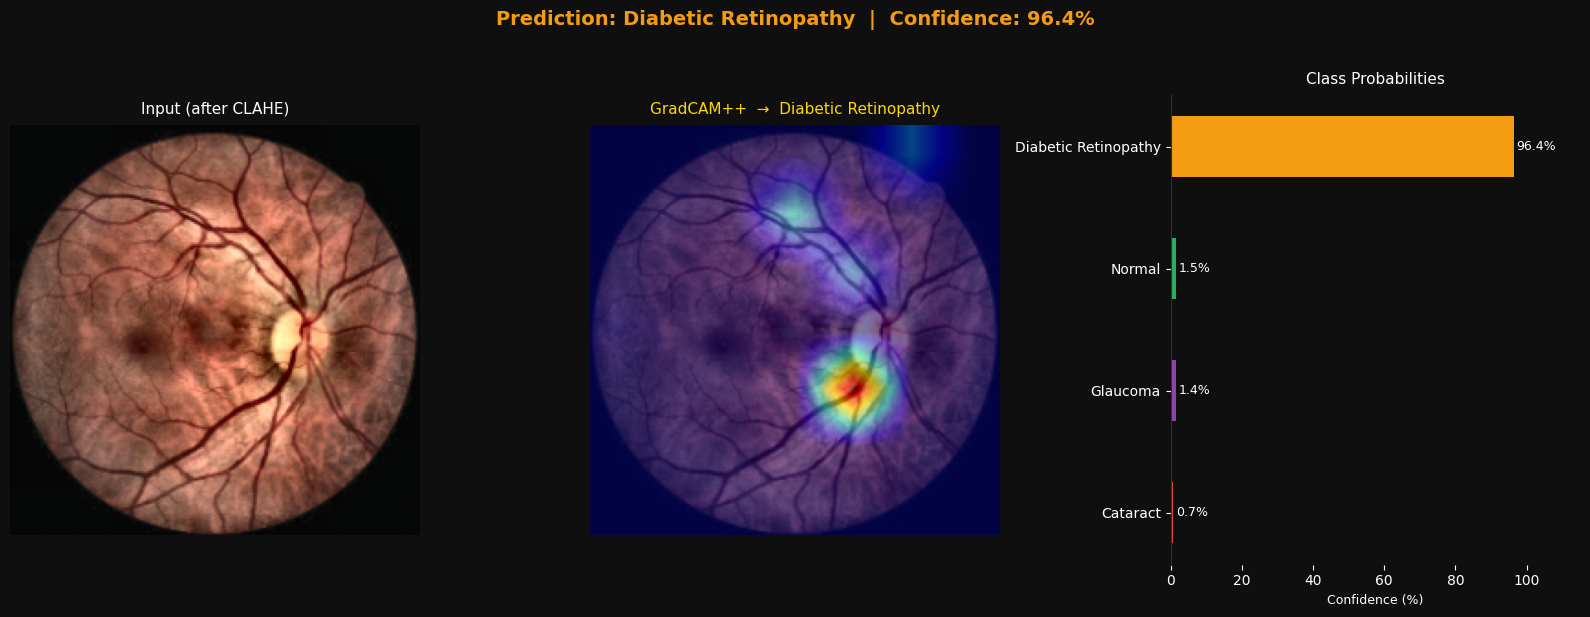


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 011938.png
  Prediction : Diabetic Retinopathy  (96.4%)
  CAM class  : Diabetic Retinopathy
──────────────────────────────────────────
    Cataract                    0.7%  
  ◉ Diabetic Retinopathy       96.4%  ███████████████████
    Glaucoma                    1.4%  
    Normal                      1.5%  
──────────────────────────────────────────



In [13]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)

📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 012134.png to Screenshot 2026-05-06 012134.png

✓ Uploaded: Screenshot 2026-05-06 012134.png


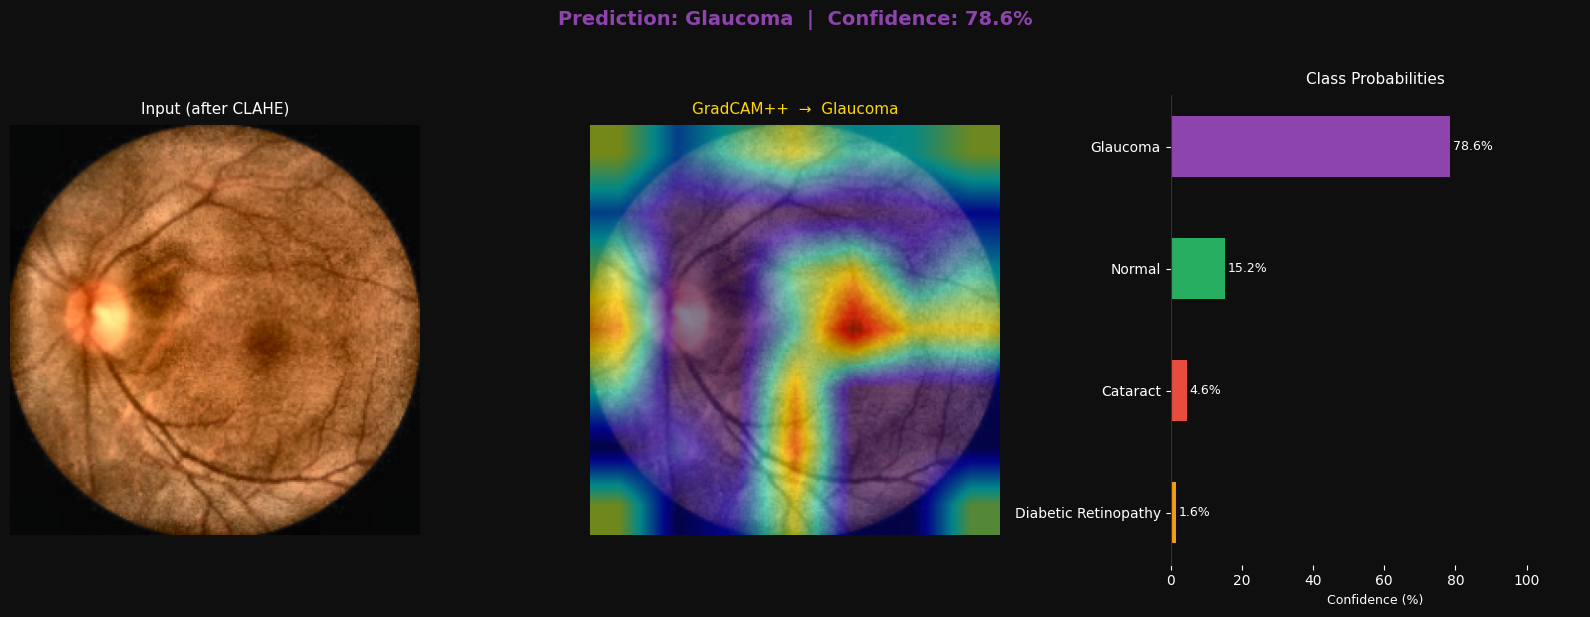


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 012134.png
  Prediction : Glaucoma  (78.6%)
  CAM class  : Glaucoma
──────────────────────────────────────────
    Cataract                    4.6%  
    Diabetic Retinopathy        1.6%  
  ◉ Glaucoma                   78.6%  ███████████████
    Normal                     15.2%  ███
──────────────────────────────────────────



In [15]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)

📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 012347.png to Screenshot 2026-05-06 012347.png

✓ Uploaded: Screenshot 2026-05-06 012347.png


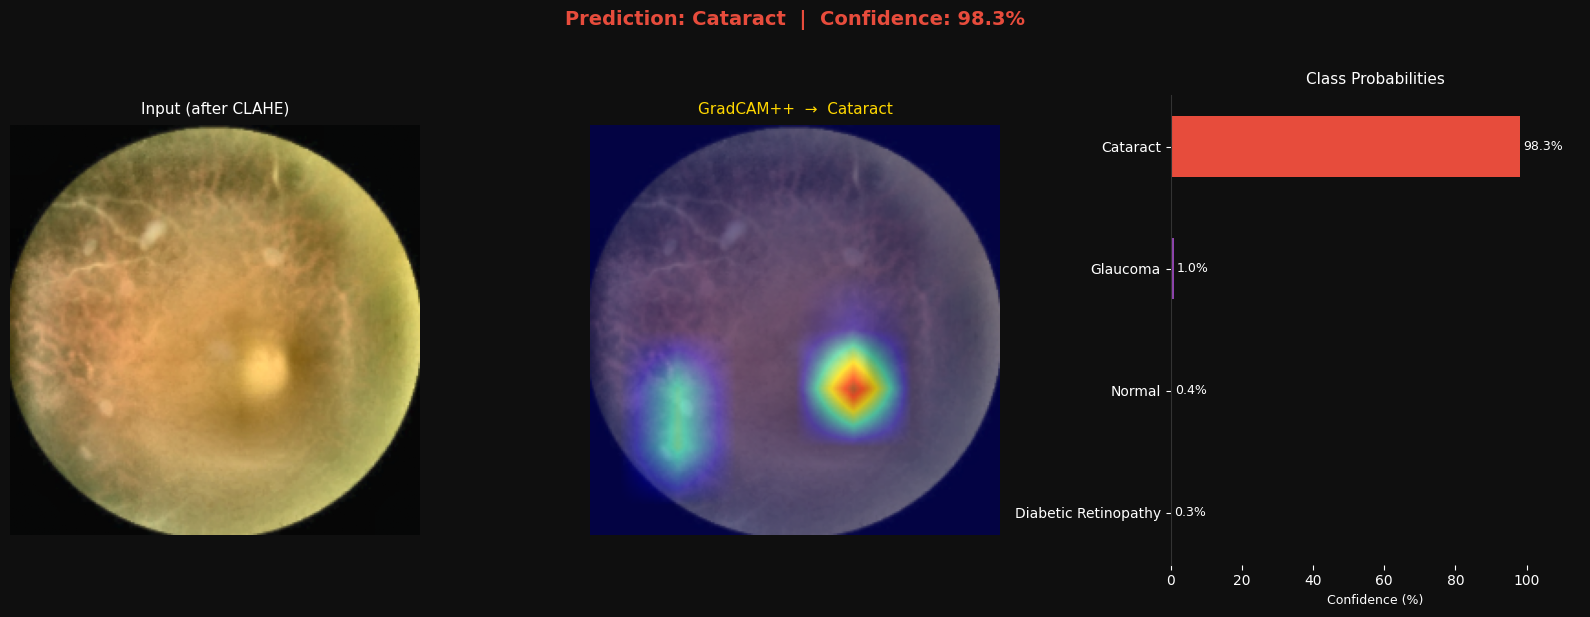


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 012347.png
  Prediction : Cataract  (98.3%)
  CAM class  : Cataract
──────────────────────────────────────────
  ◉ Cataract                   98.3%  ███████████████████
    Diabetic Retinopathy        0.3%  
    Glaucoma                    1.0%  
    Normal                      0.4%  
──────────────────────────────────────────



In [16]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)

📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 013037.png to Screenshot 2026-05-06 013037.png

✓ Uploaded: Screenshot 2026-05-06 013037.png


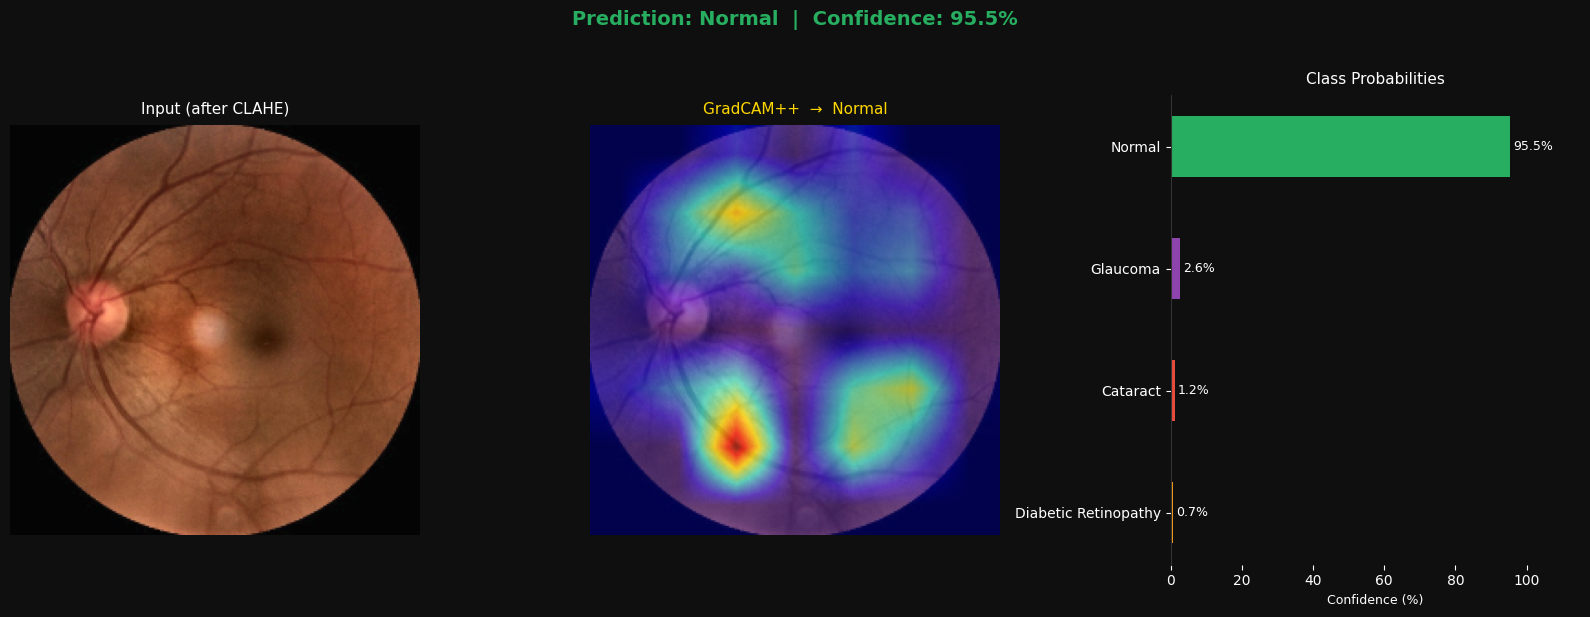


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 013037.png
  Prediction : Normal  (95.5%)
  CAM class  : Normal
──────────────────────────────────────────
    Cataract                    1.2%  
    Diabetic Retinopathy        0.7%  
    Glaucoma                    2.6%  
  ◉ Normal                     95.5%  ███████████████████
──────────────────────────────────────────



In [21]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)

📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 021926.png to Screenshot 2026-05-06 021926.png

✓ Uploaded: Screenshot 2026-05-06 021926.png


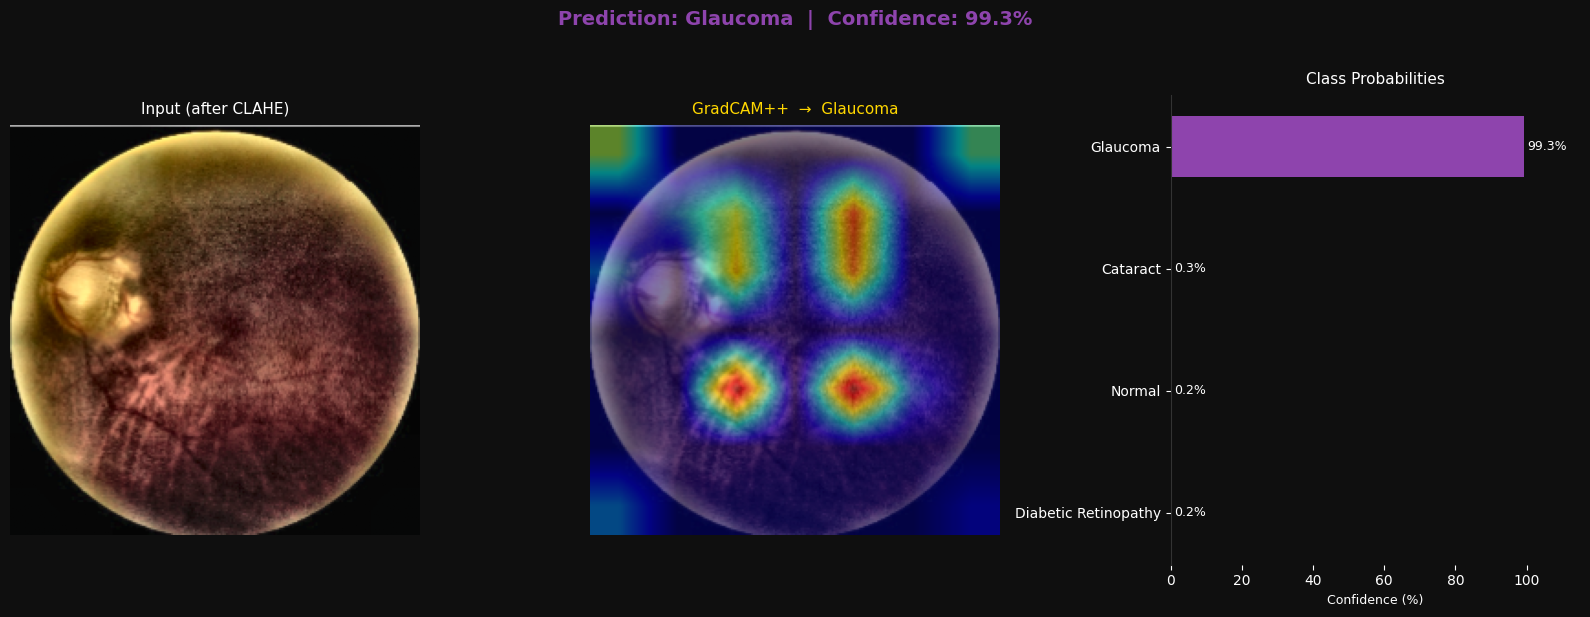


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 021926.png
  Prediction : Glaucoma  (99.3%)
  CAM class  : Glaucoma
──────────────────────────────────────────
    Cataract                    0.3%  
    Diabetic Retinopathy        0.2%  
  ◉ Glaucoma                   99.3%  ███████████████████
    Normal                      0.2%  
──────────────────────────────────────────



In [23]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)

📂 Select your retinal image file (JPG / PNG)...


Saving Screenshot 2026-05-06 022047.png to Screenshot 2026-05-06 022047.png

✓ Uploaded: Screenshot 2026-05-06 022047.png


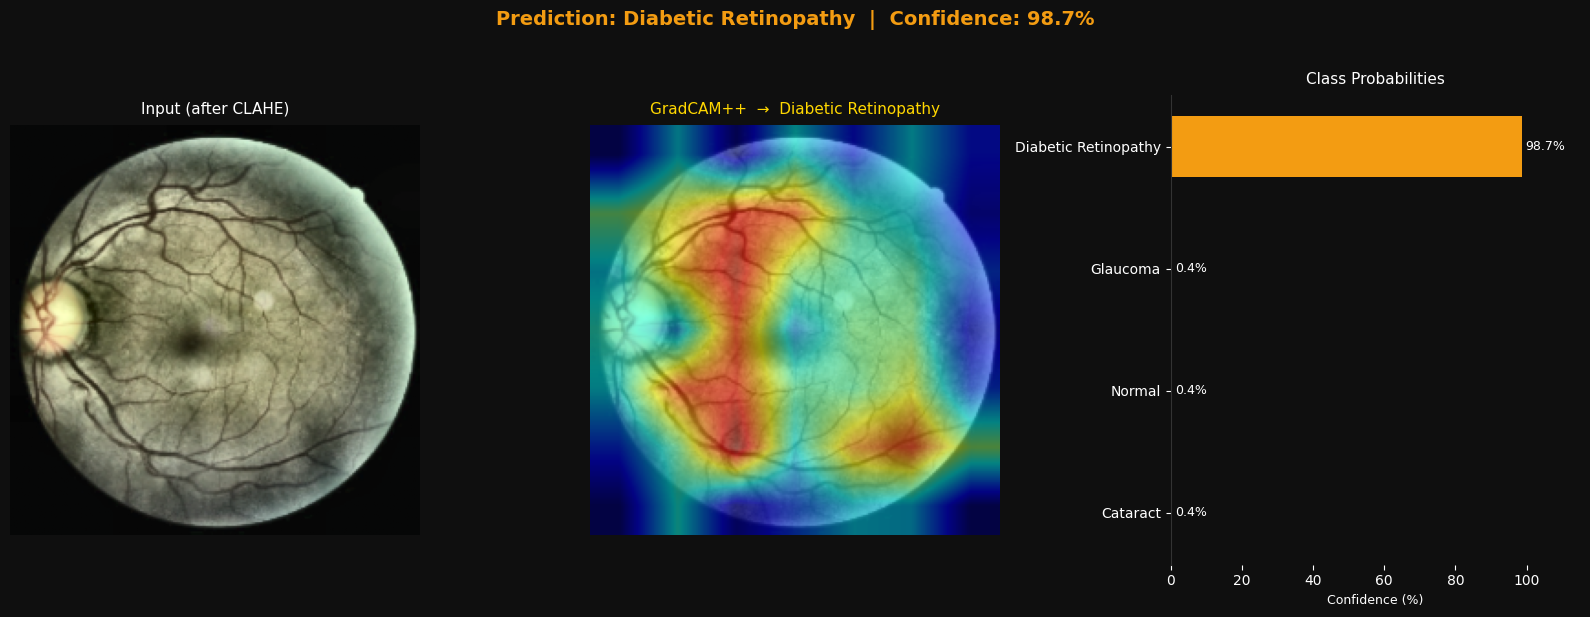


──────────────────────────────────────────
  Image      : Screenshot 2026-05-06 022047.png
  Prediction : Diabetic Retinopathy  (98.7%)
  CAM class  : Diabetic Retinopathy
──────────────────────────────────────────
    Cataract                    0.4%  
  ◉ Diabetic Retinopathy       98.7%  ███████████████████
    Glaucoma                    0.4%  
    Normal                      0.4%  
──────────────────────────────────────────



In [24]:
# =========================================================
# CELL 7: UPLOAD IMAGE AND RUN PREDICTION
# =========================================================
# ── Option A: Google Colab file upload widget ─────────────
try:
    from google.colab import files as colab_files

    print("📂 Select your retinal image file (JPG / PNG)...")
    uploaded = colab_files.upload()           # opens file picker

    if uploaded:
        IMAGE_PATH = list(uploaded.keys())[0]
        print(f"\n✓ Uploaded: {IMAGE_PATH}")
        pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)
    else:
        print("⚠️  No file uploaded.")

except ImportError:
    # ── Option B: Local path (Jupyter / VS Code) ──────────
    # Change the path below to your image file.
    IMAGE_PATH = "your_eye_image.jpg"   # ← CHANGE THIS

    print(f"Running on local file: {IMAGE_PATH}")
    pred_class, probs, cam_img = predict_and_visualise(IMAGE_PATH)